In [3]:
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("ggplot")

In [4]:
df = pd.read_csv("../data/Dataset .csv")

df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [5]:
chain_count = (
    df["Restaurant Name"]
    .value_counts()
    .reset_index()
)

chain_count.columns = [
    "Restaurant Name",
    "Number of Outlets"
]

chains = chain_count[
    chain_count["Number of Outlets"] > 1
]

chains.head(10)

,Restaurant Name,Number of Outlets
0,Cafe Coffee Day,83
1,Domino's Pizza,79
2,Subway,63
3,Green Chick Chop,51
4,McDonald's,48
5,Keventers,34
6,Pizza Hut,30
7,Giani,29
8,Baskin Robbins,28
9,Barbeque Nation,26


In [6]:
print("Total Restaurant Chains:", len(chains))

Total Restaurant Chains: 734


In [7]:
top_chains = chains.head(10)

top_chains

,Restaurant Name,Number of Outlets
0,Cafe Coffee Day,83
1,Domino's Pizza,79
2,Subway,63
3,Green Chick Chop,51
4,McDonald's,48
5,Keventers,34
6,Pizza Hut,30
7,Giani,29
8,Baskin Robbins,28
9,Barbeque Nation,26


In [8]:
chain_rating = (
    df.groupby("Restaurant Name")
      .agg(
          Average_Rating=("Aggregate rating", "mean"),
          Average_Votes=("Votes", "mean"),
          Outlets=("Restaurant Name", "count")
      )
      .reset_index()
)

chain_rating = chain_rating[
    chain_rating["Outlets"] > 1
]

chain_rating = chain_rating.sort_values(
    by="Average_Rating",
    ascending=False
)

chain_rating.head(10)

,Restaurant Name,Average_Rating,Average_Votes,Outlets
6263,Talaga Sampireun,4.900,1838.0,3
5850,Silantro Fil-Mex,4.850,682.0,2
102,AB's Absolute Barbecues,4.850,1575.5,2
101,AB's - Absolute Barbecues,4.825,3350.0,4
4464,Naturals Ice Cream,4.800,1547.0,2
2806,Gymkhana,4.700,164.0,2
6504,The Cheesecake Factory,4.650,1505.0,2
2585,Garota de Ipanema,4.600,29.5,2
2076,Dishoom,4.600,634.5,2
1510,Chili's,4.580,1631.2,5


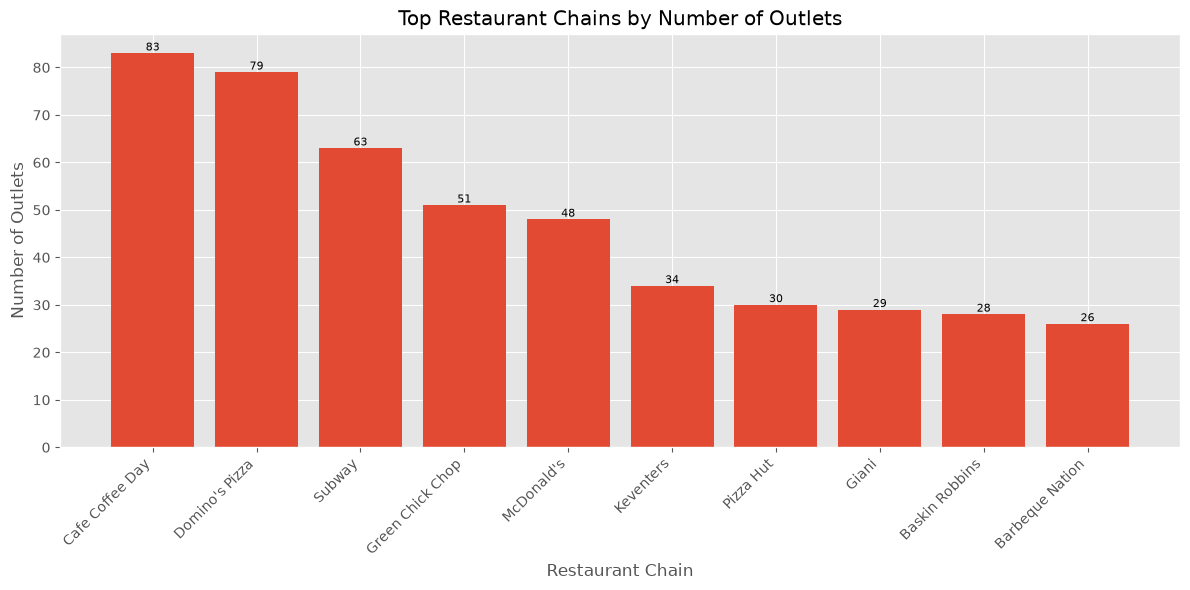

In [9]:
plt.figure(figsize=(12,6))

bars = plt.bar(
    top_chains["Restaurant Name"],
    top_chains["Number of Outlets"]
)

plt.xticks(rotation=45, ha="right")

plt.title("Top Restaurant Chains by Number of Outlets")
plt.xlabel("Restaurant Chain")
plt.ylabel("Number of Outlets")

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        int(bar.get_height()),
        ha="center",
        va="bottom",
        fontsize=8
    )

plt.tight_layout()
plt.show()

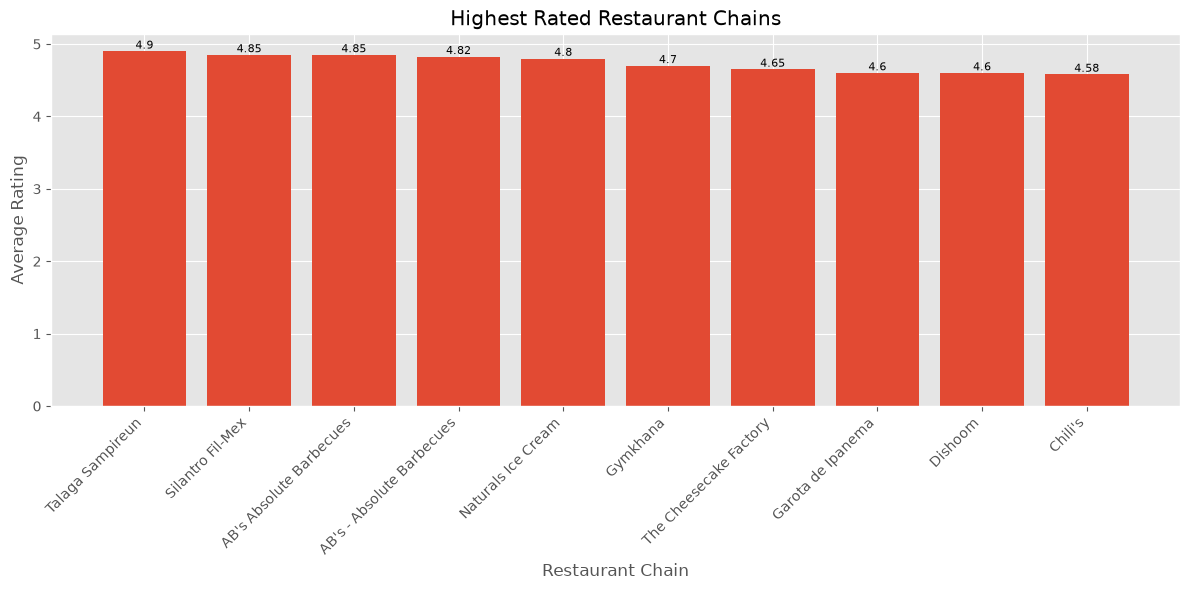

In [10]:
best_chain = (
    chain_rating
    .sort_values(
        by="Average_Rating",
        ascending=False
    )
    .head(10)
)

plt.figure(figsize=(12,6))

bars = plt.bar(
    best_chain["Restaurant Name"],
    best_chain["Average_Rating"]
)

plt.xticks(rotation=45, ha="right")

plt.title("Highest Rated Restaurant Chains")
plt.xlabel("Restaurant Chain")
plt.ylabel("Average Rating")

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        round(bar.get_height(),2),
        ha="center",
        va="bottom",
        fontsize=8
    )

plt.tight_layout()
plt.show()

In [11]:
popular = (
    chain_rating
    .sort_values(
        by="Average_Votes",
        ascending=False
    )
    .head(10)
)

popular

,Restaurant Name,Average_Rating,Average_Votes,Outlets
6988,Truffles,3.950000,4841.000000,2
3261,Joey's Pizza,4.250000,3903.500000,2
101,AB's - Absolute Barbecues,4.825000,3350.000000,4
785,Big Chill,4.475000,2713.250000,4
796,Big Yellow Door,4.266667,2503.666667,3
4735,Out Of The Box,3.850000,2450.000000,2
5571,Saravana Bhavan,4.133333,2412.666667,3
4678,Olive Bistro,4.150000,1854.000000,2
6263,Talaga Sampireun,4.900000,1838.000000,3
6030,SpiceKlub,4.300000,1825.500000,2


In [12]:
chain_rating.head(20)

,Restaurant Name,Average_Rating,Average_Votes,Outlets
6263,Talaga Sampireun,4.900000,1838.000000,3
5850,Silantro Fil-Mex,4.850000,682.000000,2
102,AB's Absolute Barbecues,4.850000,1575.500000,2
101,AB's - Absolute Barbecues,4.825000,3350.000000,4
4464,Naturals Ice Cream,4.800000,1547.000000,2
2806,Gymkhana,4.700000,164.000000,2
6504,The Cheesecake Factory,4.650000,1505.000000,2
2585,Garota de Ipanema,4.600000,29.500000,2
2076,Dishoom,4.600000,634.500000,2
1510,Chili's,4.580000,1631.200000,5


# Observations

- Identified restaurant chains by finding restaurant names with multiple outlets.
- Calculated the number of outlets for each chain.
- Analyzed the average ratings and average votes for restaurant chains.
- Identified the most widespread restaurant chains.
- Compared the highest-rated and most popular chains using visualizations.
- The analysis highlights how restaurant chains perform in terms of customer satisfaction and popularity.